In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'/content/drive/MyDrive/TP2_reseau_neurones/Wang.zip'

'/content/drive/MyDrive/TP2_reseau_neurones/Wang.zip'

In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/TP2_reseau_neurones/Wang.zip"
extract_dir = "/content/Wang"  # Dossier de destination dans Colab

# Créer le dossier s'il n'existe pas
os.makedirs(extract_dir, exist_ok=True)

# Extraire le contenu du ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extrait dans :", extract_dir)


Dataset extrait dans : /content/Wang


In [ ]:
import os
print(os.listdir("/content/Wang/Wang")[:10])  # Affiche les 10 premières images

['274.jpg', '446.jpg', '391.jpg', '957.jpg', '128.jpg', '339.jpg', '868.jpg', '572.jpg', '85.jpg', '147.jpg']


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

base_dir = "/content/Wang/Wang"

classes = ["Jungle","Plage","Monuments","Bus","Dinosaures",
           "Elephants","Fleurs","Chevaux","Montagne","Plats"]

images = []
labels = []

all_images = sorted(os.listdir(base_dir))  # garde l’ordre 0..999

for i, img_name in enumerate(all_images):
    img_path = os.path.join(base_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (256, 256))
    images.append(img)

    # chaque 100 images = une classe
    class_index = i // 100
    labels.append(class_index)

images = np.array(images)
labels = np.array(labels)

print("Taille dataset :", images.shape, labels.shape)


Taille dataset : (1000, 256, 256, 3) (1000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"Train : {X_train.shape}, Val : {X_val.shape}, Test : {X_test.shape}")

Train : (600, 256, 256, 3), Val : (200, 256, 256, 3), Test : (200, 256, 256, 3)


In [ ]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

datagen.fit(X_train)


model = keras.models.Sequential([
    keras.layers.Conv2D(64, 3, padding="same", activation="relu", input_shape=[256, 256, 3]),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),

    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),

    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)


history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,048,714 (65.04 MB)

 Trainable params: 17,047,562 (65.03 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 864ms/step - accuracy: 0.1558 - loss: 3.0686 - val_accuracy: 0.1400 - val_loss: 23.6005
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.3095 - loss: 2.1764 - val_accuracy: 0.2300 - val_loss: 13.5649
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 513ms/step - accuracy: 0.3313 - loss: 2.0694 - val_accuracy: 0.1750 - val_loss: 10.6465
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 570ms/step - accuracy: 0.3910 - loss: 1.8300 - val_accuracy: 0.2750 - val_loss: 6.0577
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 566ms/step - accuracy: 0.3925 - loss: 1.8507 - val_accuracy: 0.3450 - val_loss: 3.4777
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 572ms/step - accuracy: 0.4019 - loss: 1.8488 - val_accuracy: 0.4250 - val_loss: 1.7358
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 532ms/step - accuracy: 0.4153 - loss: 1.5891 - val_accuracy: 0.4300 - val_loss: 1.6962
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 511ms/step - accuracy: 0.4332 - loss: 1.7113 - val_a

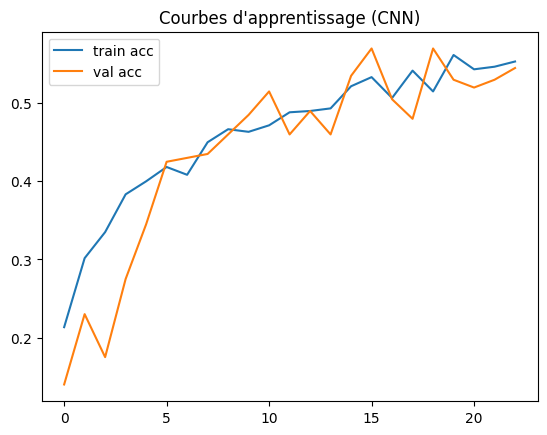

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Courbes d'apprentissage (CNN)")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6063 - loss: 1.3412
Accuracy test : 0.595
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
              precision    recall  f1-score   support

      Jungle       0.65      0.55      0.59        20
       Plage       0.32      0.69      0.44        13
   Monuments       0.64      0.67      0.65        27
         Bus       0.53      0.38      0.44        21
  Dinosaures       0.57      0.53      0.55        15
   Elephants       0.69      0.41      0.51        22
      Fleurs       0.76      0.64      0.70        25
     Chevaux       0.61      0.85      0.71        13
    Montagne       0.62      0.57      0.59        23
       Plats       0.64      0.76      0.70        21

    accuracy                           0.59       200
   macro avg       0.60      0.60      0.59       200
weighted avg       0.62      0.59      0.60       200



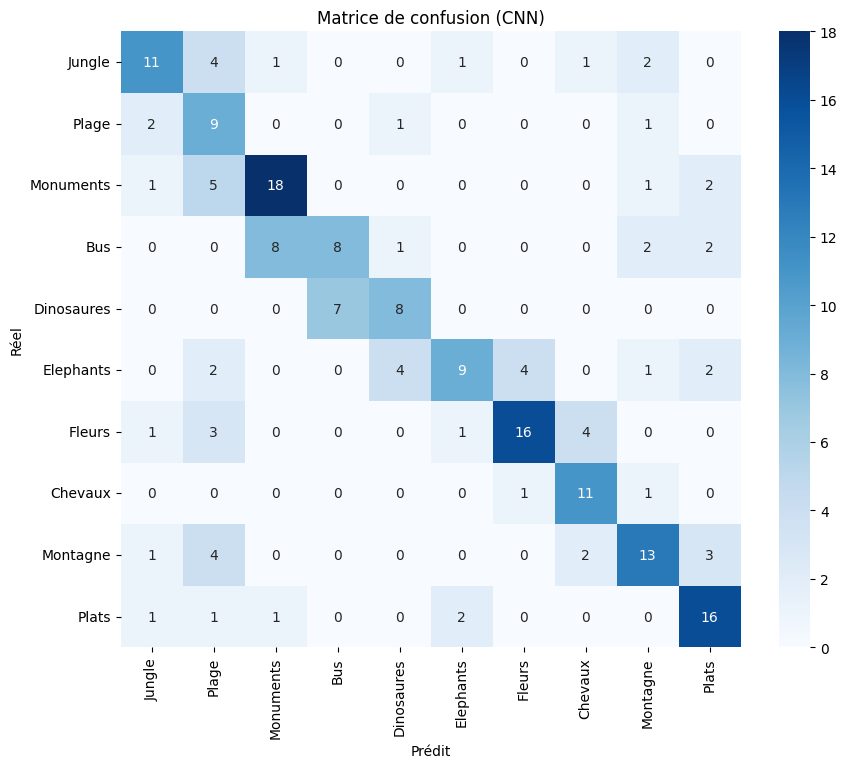

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import seaborn as sns

# Évaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Accuracy test : {test_acc:.3f}")

# Prédictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Rapport détaillé
print(classification_report(y_test, y_pred, target_names=classes))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion (CNN)")
plt.show()
